# 스타티(Startie) 채널 분석 (발표자료 2부)
분석 기간: **2025-03-01 ~ 2025-05-31 (signup_date 기준)**


## Step 1. 채널별 유입 규모 확인
코드 설명:
- 분석 기간(2025-03~05) 스냅샷에서 채널별 가입자 수와 비중을 집계합니다.
- 유입 상위 채널을 식별해 집행 후보군을 확인합니다.



,acquisition_source,signups,share_pct
1,google_ads,"2,071",20.1%
4,organic,"2,040",19.8%
6,youtube,"1,837",17.8%
0,content_marketing,"1,442",14.0%
3,meta_ads,"1,306",12.7%
5,referral,828,8.0%
2,instagram_influencer,787,7.6%


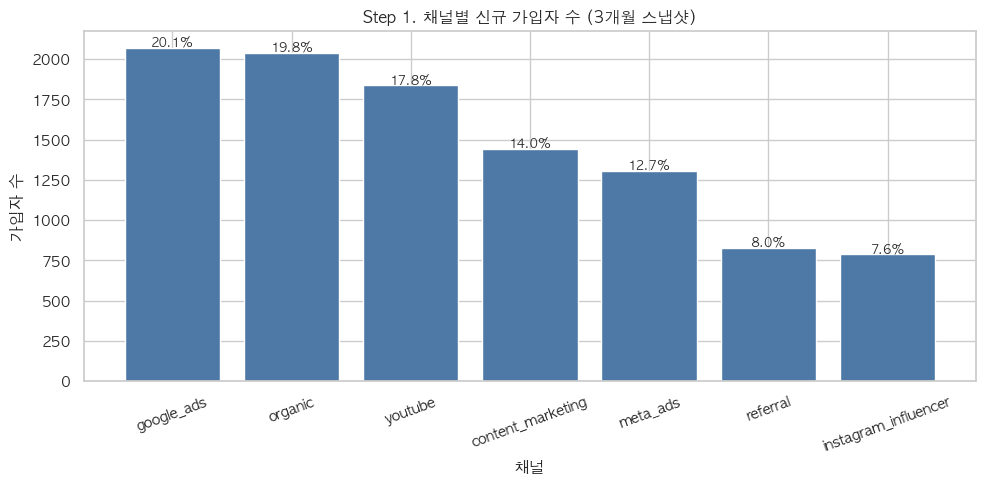

Top3 유입 채널: google_ads, organic, youtube


In [446]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager

u = pd.read_csv('data/users.csv', parse_dates=['signup_date']).query("signup_date >= '2025-03-01' and signup_date <= '2025-05-31'").copy()
font_candidates = ['NanumGothic', 'Malgun Gothic', 'AppleGothic']
installed = {f.name for f in font_manager.fontManager.ttflist}
for f in font_candidates:
    if f in installed:
        plt.rcParams['font.family'] = f
        break
plt.rcParams['axes.unicode_minus'] = False

step1_df = (
    u.groupby('acquisition_source', as_index=False)
     .agg(signups=('user_id', 'count'))
     .sort_values('signups', ascending=False)
)
step1_df['share_pct'] = (step1_df['signups'] / step1_df['signups'].sum() * 100).round(1)

styled = step1_df.style.format({'signups': '{:,.0f}', 'share_pct': '{:.1f}%'}).highlight_max(subset=['signups'], color='#fff2cc')
display(styled)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(step1_df['acquisition_source'], step1_df['signups'], color='#4e79a7')
for b, pct in zip(bars, step1_df['share_pct']):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)
ax.set_title('Step 1. 채널별 신규 가입자 수 (3개월 스냅샷)')
ax.set_xlabel('채널')
ax.set_ylabel('가입자 수')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

top3 = step1_df.head(3)
print('Top3 유입 채널:', ', '.join(top3['acquisition_source']))



## Step 1-1. 전체기간 Growth 추이 (MAU / 총매출)
코드 설명:
- 전체 데이터 기간 기준으로 월별 MAU와 총매출을 집계합니다.
- 투자자 관점에서 초기 비즈니스의 우상향 성장 흐름을 확인합니다.


,month,MAU,total_revenue
0,2025-01,"3,671","19,627,400"
1,2025-02,"4,813","30,441,000"
2,2025-03,"6,592","51,069,500"
3,2025-04,"8,481","69,833,100"
4,2025-05,"9,711","77,628,500"


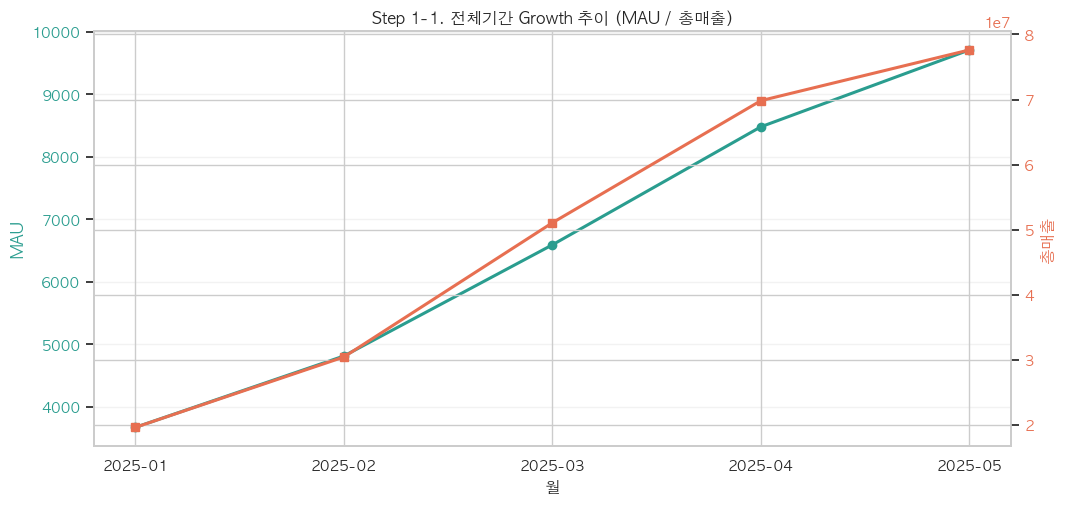

In [447]:
import pandas as pd
import matplotlib.pyplot as plt

users_all = pd.read_csv('data/users.csv', parse_dates=['signup_date'])
events = pd.read_csv('data/event_logs.csv', parse_dates=['event_timestamp'])
pay = pd.read_csv('data/payment_transactions.csv', parse_dates=['transaction_date'])

all_user_ids = set(users_all['user_id'])

ev = events[events['user_id'].isin(all_user_ids)].copy()
ev['month'] = ev['event_timestamp'].dt.to_period('M').astype(str)
mau = ev.groupby('month', as_index=False).agg(MAU=('user_id', 'nunique'))

pay_ok = pay[(pay['status'] == 'completed') & (pay['user_id'].isin(all_user_ids))].copy()
pay_ok['month'] = pay_ok['transaction_date'].dt.to_period('M').astype(str)
rev = pay_ok.groupby('month', as_index=False).agg(total_revenue=('amount', 'sum'))

growth_df = pd.merge(mau, rev, on='month', how='outer').fillna(0).sort_values('month')

display(growth_df.style.format({'MAU':'{:,.0f}', 'total_revenue':'{:,.0f}'}))

fig, ax1 = plt.subplots(figsize=(10.8, 5.2))
ax1.plot(growth_df['month'], growth_df['MAU'], color='#2a9d8f', marker='o', linewidth=2.2)
ax1.set_ylabel('MAU', color='#2a9d8f')
ax1.tick_params(axis='y', labelcolor='#2a9d8f')

ax2 = ax1.twinx()
ax2.plot(growth_df['month'], growth_df['total_revenue'], color='#e76f51', marker='s', linewidth=2.2)
ax2.set_ylabel('총매출', color='#e76f51')
ax2.tick_params(axis='y', labelcolor='#e76f51')

ax1.set_title('Step 1-1. 전체기간 Growth 추이 (MAU / 총매출)')
ax1.set_xlabel('월')
ax1.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


## Step 2. 채널별 유료전환율 분석 (메인 KPI)
코드 설명:
- `plan_history(action=subscribe)`를 기준으로 유료전환율을 계산합니다.
- 유입량과 별개로 채널 품질(CVR) 차이를 확인합니다.



,acquisition_source,signups,paid_users,paid_conversion_pct
5,referral,828,275,33.2%
1,google_ads,"2,071",640,30.9%
6,youtube,"1,837",529,28.8%
4,organic,"2,040",486,23.8%
0,content_marketing,"1,442",317,22.0%
2,instagram_influencer,787,157,19.9%
3,meta_ads,"1,306",230,17.6%


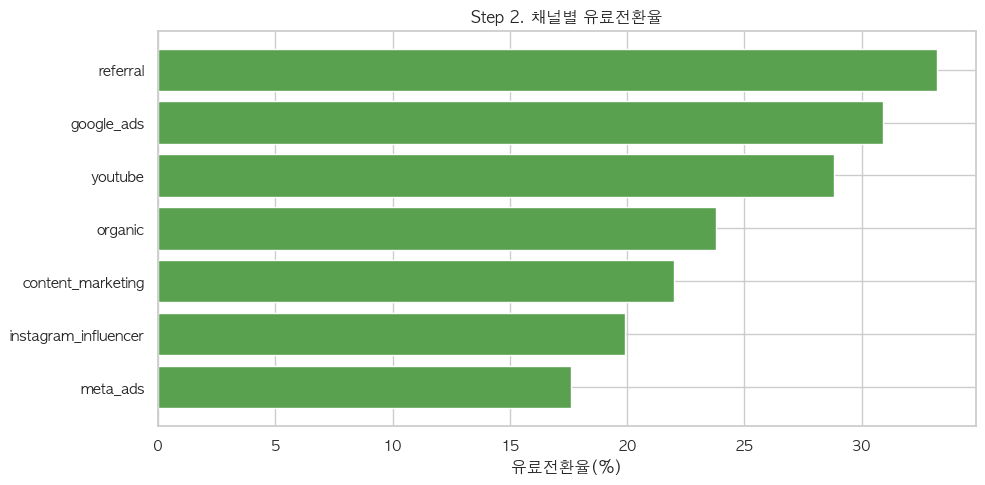

유료전환율 상위 채널: referral
유료전환율 하위 채널: meta_ads


In [448]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager

u = pd.read_csv('data/users.csv', parse_dates=['signup_date']).query("signup_date >= '2025-03-01' and signup_date <= '2025-05-31'").copy()
plan = pd.read_csv('data/plan_history.csv', parse_dates=['action_date'])
font_candidates = ['NanumGothic', 'Malgun Gothic', 'AppleGothic']
installed = {f.name for f in font_manager.fontManager.ttflist}
for f in font_candidates:
    if f in installed:
        plt.rcParams['font.family'] = f
        break
plt.rcParams['axes.unicode_minus'] = False

paid_users = set(plan.loc[plan['action'] == 'subscribe', 'user_id'])
u['is_paid'] = u['user_id'].isin(paid_users)

step2_df = (
    u.groupby('acquisition_source', as_index=False)
     .agg(signups=('user_id', 'count'), paid_users=('is_paid', 'sum'))
)
step2_df['paid_conversion_pct'] = (step2_df['paid_users'] / step2_df['signups'] * 100).round(1)
step2_df = step2_df.sort_values('paid_conversion_pct', ascending=False)

styled = step2_df.style.format({
    'signups':'{:,.0f}',
    'paid_users':'{:,.0f}',
    'paid_conversion_pct':'{:.1f}%'
}).highlight_max(subset=['paid_conversion_pct'], color='#d9ead3')   .highlight_min(subset=['paid_conversion_pct'], color='#f4cccc')
display(styled)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(step2_df['acquisition_source'][::-1], step2_df['paid_conversion_pct'][::-1], color='#59a14f')
ax.set_title('Step 2. 채널별 유료전환율')
ax.set_xlabel('유료전환율(%)')
plt.tight_layout()
plt.show()

print('유료전환율 상위 채널:', step2_df.iloc[0]['acquisition_source'])
print('유료전환율 하위 채널:', step2_df.iloc[-1]['acquisition_source'])
# 인사이트: 본 분석의 메인 KPI는 유료전환율이며, 채널 확장/축소 판단의 1차 기준으로 사용한다.




## Step 3. 채널별 매출액 vs 유료전환율
코드 설명:
- 채널별 총매출과 유료전환율을 함께 비교해 확장/개선 채널을 구분합니다.
- 볼륨 기반 매출 기여와 전환 품질을 동시에 진단합니다.



,acquisition_source,signups,paid_users,paid_conversion_pct,revenue,revenue_share_pct,arpu
0,google_ads,"2,071",640,30.9%,"40,076,900",25.8%,"19,351.5"
1,youtube,"1,837",529,28.8%,"31,421,600",20.2%,"17,104.8"
2,organic,"2,040",486,23.8%,"29,301,100",18.9%,"14,363.3"
3,content_marketing,"1,442",317,22.0%,"17,523,800",11.3%,"12,152.4"
4,referral,828,275,33.2%,"15,827,500",10.2%,"19,115.3"
5,meta_ads,"1,306",230,17.6%,"12,178,300",7.8%,"9,324.9"
6,instagram_influencer,787,157,19.9%,"8,994,900",5.8%,"11,429.4"


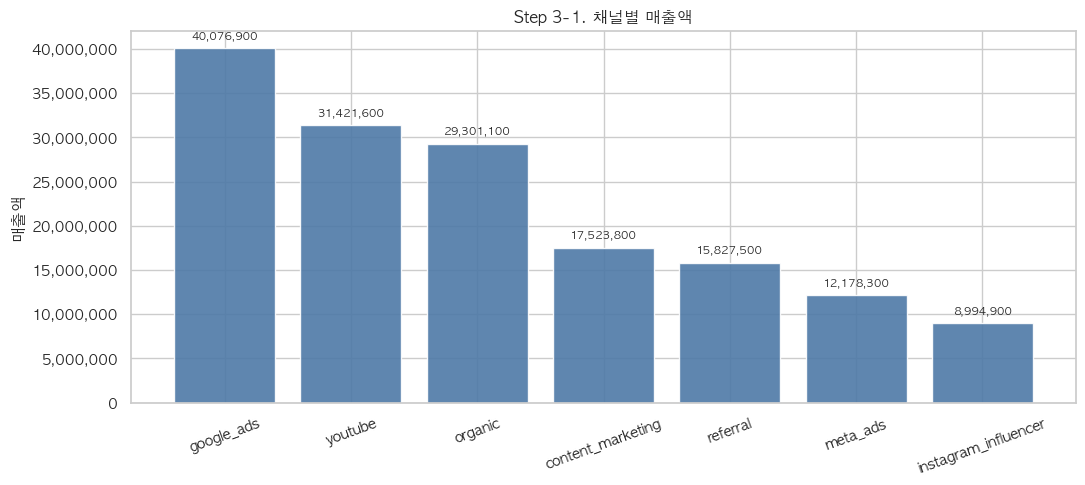

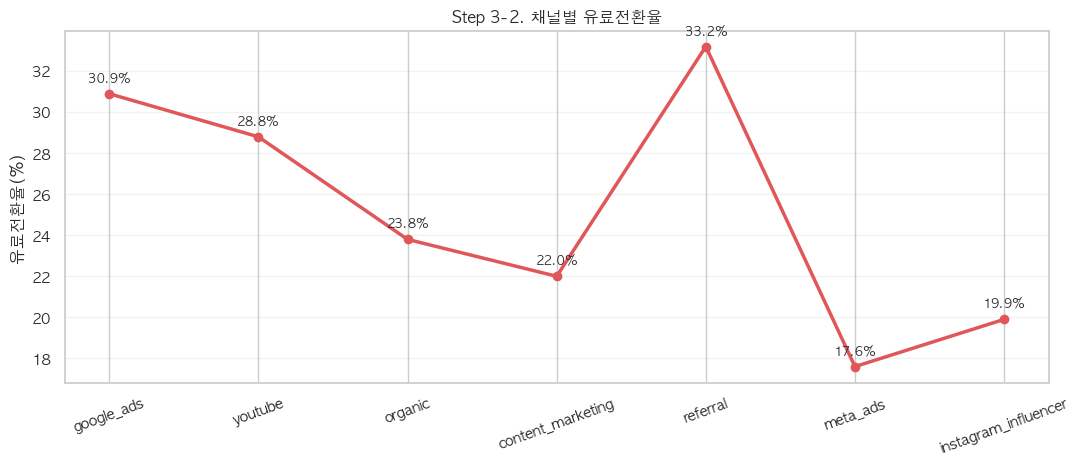

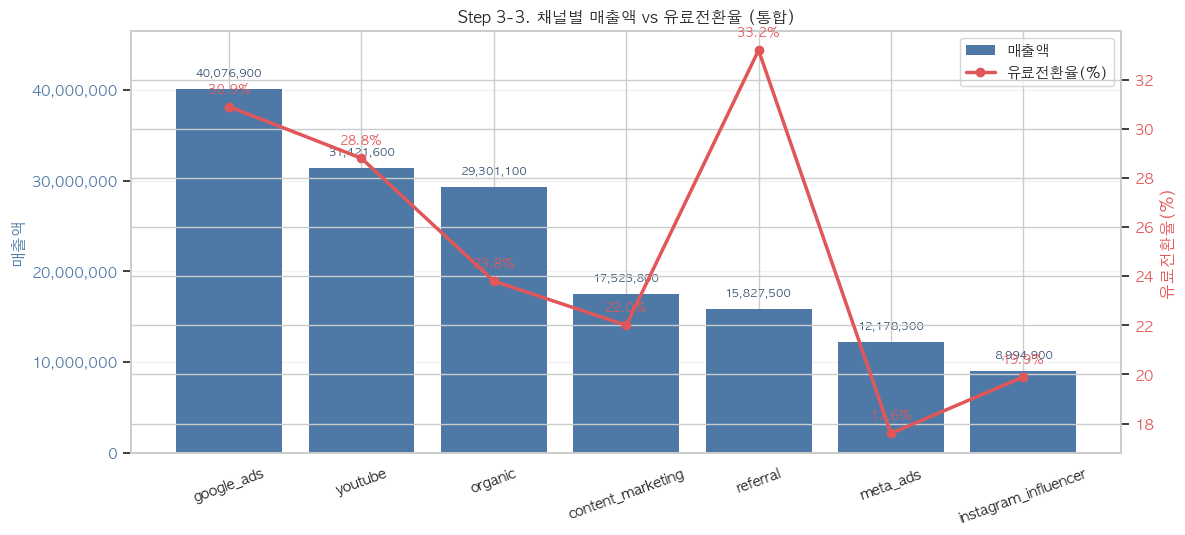

확장 우선(매출↑·전환↑): google_ads, youtube
전환 개선 우선(매출↑·전환↓): organic


In [449]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager
from matplotlib.ticker import FuncFormatter

# Step 2 결과가 없으면 복구 계산
if 'step2_df' not in globals():
    u = pd.read_csv('data/users.csv', parse_dates=['signup_date']).query("signup_date >= '2025-03-01' and signup_date <= '2025-05-31'").copy()
    plan = pd.read_csv('data/plan_history.csv', parse_dates=['action_date'])
    paid_users = set(plan.loc[plan['action'] == 'subscribe', 'user_id'])
    u['is_paid'] = u['user_id'].isin(paid_users)

    step2_df = (
        u.groupby('acquisition_source', as_index=False)
         .agg(signups=('user_id', 'count'), paid_users=('is_paid', 'sum'))
    )
    step2_df['paid_conversion_pct'] = (step2_df['paid_users'] / step2_df['signups'] * 100).round(1)

u = pd.read_csv('data/users.csv', parse_dates=['signup_date']).query("signup_date >= '2025-03-01' and signup_date <= '2025-05-31'").copy()
pay = pd.read_csv('data/payment_transactions.csv', parse_dates=['transaction_date'])

font_candidates = ['NanumGothic', 'Malgun Gothic', 'AppleGothic']
installed = {f.name for f in font_manager.fontManager.ttflist}
for f in font_candidates:
    if f in installed:
        plt.rcParams['font.family'] = f
        break
plt.rcParams['axes.unicode_minus'] = False

rev_user = (
    pay.loc[pay['status'] == 'completed', ['user_id', 'amount']]
       .groupby('user_id', as_index=False)
       .agg(revenue=('amount', 'sum'))
)

rev_channel = (
    u[['user_id', 'acquisition_source']]
    .merge(rev_user, on='user_id', how='left')
    .fillna({'revenue': 0})
    .groupby('acquisition_source', as_index=False)
    .agg(revenue=('revenue', 'sum'))
)

step3_df = (
    step2_df[['acquisition_source', 'signups', 'paid_users', 'paid_conversion_pct']]
    .merge(rev_channel, on='acquisition_source', how='left')
    .fillna({'revenue': 0})
)
step3_df['revenue_share_pct'] = (step3_df['revenue'] / step3_df['revenue'].sum() * 100).round(1)
step3_df['arpu'] = (step3_df['revenue'] / step3_df['signups']).round(1)
step3_df = step3_df.sort_values('revenue', ascending=False).reset_index(drop=True)

styled = step3_df.style.format({
    'signups': '{:,.0f}',
    'paid_users': '{:,.0f}',
    'paid_conversion_pct': '{:.1f}%',
    'revenue': '{:,.0f}',
    'revenue_share_pct': '{:.1f}%',
    'arpu': '{:,.1f}'
}).highlight_max(subset=['revenue', 'paid_conversion_pct', 'revenue_share_pct'], color='#d9ead3')
display(styled)

plot_df = step3_df.copy()
labels = plot_df['acquisition_source']
x = np.arange(len(labels))

# 1) 매출액 단독 막대그래프
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(x, plot_df['revenue'], color='#4e79a7', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20)
ax.set_title('Step 3-1. 채널별 매출액')
ax.set_ylabel('매출액')
ax.ticklabel_format(style='plain', axis='y')
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y):,}"))
max_rev = plot_df['revenue'].max()
rev_offset = max_rev * 0.02 if max_rev > 0 else 1
for b in bars:
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + rev_offset,
        f"{b.get_height():,.0f}",
        ha='center',
        va='bottom',
        fontsize=8
    )
plt.tight_layout()
plt.show()

# 2) 유료전환율 단독 꺾은선그래프
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(x, plot_df['paid_conversion_pct'], color='#e15759', marker='o', linewidth=2.5)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20)
ax.set_title('Step 3-2. 채널별 유료전환율')
ax.set_ylabel('유료전환율(%)')
for xi, yi in zip(x, plot_df['paid_conversion_pct']):
    ax.text(xi, yi + 0.5, f"{yi:.1f}%", ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# 3) 합친 그래프 (막대=매출액, 꺾은선=유료전환율)
fig, ax1 = plt.subplots(figsize=(12, 5.5))
bars = ax1.bar(
    x,
    plot_df['revenue'],
    color='#4e79a7',
    alpha=1.0,          # Step 3-1처럼 꽉 찬 막대
    edgecolor='#4e79a7',
    linewidth=0.0,
    label='매출액',
    zorder=2
)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=20)
ax1.set_ylabel('매출액', color='#4e79a7')
ax1.tick_params(axis='y', labelcolor='#4e79a7')
ax1.ticklabel_format(style='plain', axis='y')  # 1e7 과학표기 제거
ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y):,}"))
ax1.grid(axis='y', alpha=0.25)

max_rev = plot_df['revenue'].max()
rev_offset = max_rev * 0.03 if max_rev > 0 else 1
ax1.set_ylim(0, max_rev * 1.16 if max_rev > 0 else 1)
for b in bars:
    ax1.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + rev_offset,
        f"{b.get_height():,.0f}",
        ha='center',
        va='bottom',
        fontsize=8,
        color='#2f4b6e'
    )

ax2 = ax1.twinx()
line = ax2.plot(x, plot_df['paid_conversion_pct'], color='#e15759', marker='o', linewidth=2.5, label='유료전환율(%)')
ax2.set_ylabel('유료전환율(%)', color='#e15759')
ax2.tick_params(axis='y', labelcolor='#e15759')

for xi, yi in zip(x, plot_df['paid_conversion_pct']):
    ax2.text(xi, yi + 0.5, f"{yi:.1f}%", ha='center', va='bottom', fontsize=9, color='#e15759')

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')
ax1.set_title('Step 3-3. 채널별 매출액 vs 유료전환율 (통합)')
plt.tight_layout()
plt.show()

rev_mean = step3_df['revenue'].mean()
conv_mean = step3_df['paid_conversion_pct'].mean()
expand = step3_df[(step3_df['revenue'] >= rev_mean) & (step3_df['paid_conversion_pct'] >= conv_mean)]
improve = step3_df[(step3_df['revenue'] >= rev_mean) & (step3_df['paid_conversion_pct'] < conv_mean)]

print('확장 우선(매출↑·전환↑):', ', '.join(expand['acquisition_source']) if len(expand) else '없음')
print('전환 개선 우선(매출↑·전환↓):', ', '.join(improve['acquisition_source']) if len(improve) else '없음')
# 인사이트: Step 3 의사결정은 유료전환율 단일 지표가 아니라 채널별 매출 기여와 함께 판단해야 우선순위가 명확해진다.




## Step 4. 채널별 D7/D30 리텐션
코드 설명:
- 범위 리텐션(D7:1~7일, D30:15~30일)으로 채널별 유지력을 비교합니다.
- 단기 전환 이후 장기 유지 가능성을 점검합니다.



,acquisition_source,d7_retention_pct,d30_retention_pct
5,referral,89.4%,43.6%
6,youtube,88.1%,35.8%
4,organic,85.4%,33.3%
0,content_marketing,86.4%,27.4%
1,google_ads,90.7%,26.8%
2,instagram_influencer,85.8%,22.0%
3,meta_ads,85.7%,13.3%


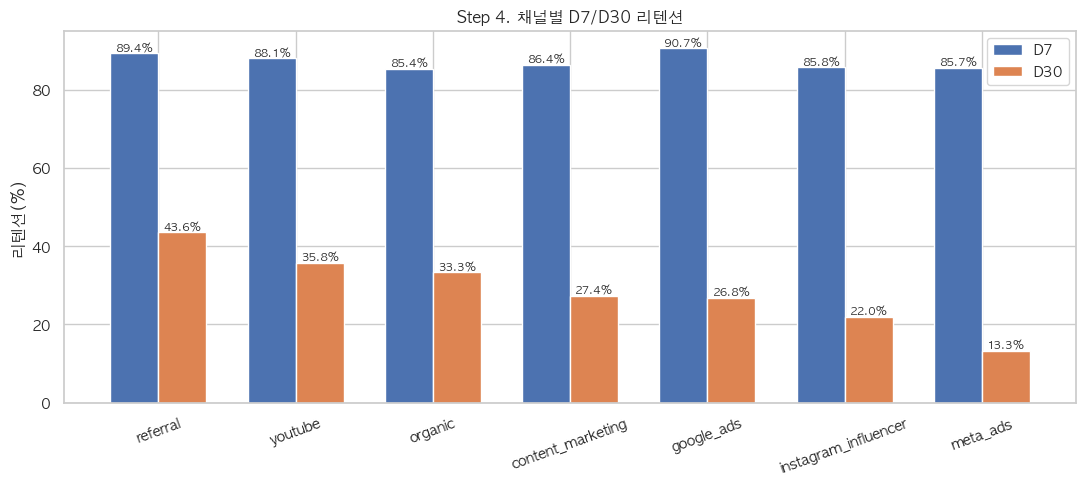

In [450]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager

u = pd.read_csv('data/users.csv', parse_dates=['signup_date']).query("signup_date >= '2025-03-01' and signup_date <= '2025-05-31'").copy()
events = pd.read_csv('data/event_logs.csv', parse_dates=['event_timestamp'])
font_candidates = ['NanumGothic', 'Malgun Gothic', 'AppleGothic']
installed = {f.name for f in font_manager.fontManager.ttflist}
for f in font_candidates:
    if f in installed:
        plt.rcParams['font.family'] = f
        break
plt.rcParams['axes.unicode_minus'] = False

ev = events.merge(u[['user_id', 'signup_date', 'acquisition_source']], on='user_id', how='inner')
ev['event_date'] = ev['event_timestamp'].dt.normalize()
ev['gap_days'] = (ev['event_date'] - ev['signup_date']).dt.days

u['ret_d7'] = u['user_id'].isin(ev.loc[ev['gap_days'].between(1, 7), 'user_id'])
u['ret_d30'] = u['user_id'].isin(ev.loc[ev['gap_days'].between(15, 30), 'user_id'])

step4_df = (
    u.groupby('acquisition_source', as_index=False)
     .agg(signups=('user_id', 'count'), d7_users=('ret_d7', 'sum'), d30_users=('ret_d30', 'sum'))
)
step4_df['d7_retention_pct'] = (step4_df['d7_users'] / step4_df['signups'] * 100).round(1)
step4_df['d30_retention_pct'] = (step4_df['d30_users'] / step4_df['signups'] * 100).round(1)
step4_df = step4_df.sort_values('d30_retention_pct', ascending=False)

display(step4_df[['acquisition_source', 'd7_retention_pct', 'd30_retention_pct']].style.format({'d7_retention_pct':'{:.1f}%','d30_retention_pct':'{:.1f}%'}).highlight_max(subset=['d30_retention_pct'], color='#d9ead3'))

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(step4_df))
w = 0.35
bars1 = ax.bar(x - w/2, step4_df['d7_retention_pct'], width=w, label='D7')
bars2 = ax.bar(x + w/2, step4_df['d30_retention_pct'], width=w, label='D30')
for b in bars1:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h, f'{h:.1f}%', ha='center', va='bottom', fontsize=8)
for b in bars2:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h, f'{h:.1f}%', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(step4_df['acquisition_source'], rotation=20)
ax.set_ylabel('리텐션(%)')
ax.set_title('Step 4. 채널별 D7/D30 리텐션')
ax.legend()
plt.tight_layout()
plt.show()

# 인사이트: D30 리텐션 상위 채널과 유입 상위 채널이 다르면, 양적 확대보다 질적 채널 최적화가 유효하다.
# 인사이트: 장기 잔존(D30) 우위 채널은 LTV 개선의 선행지표로 해석할 수 있다.



## Step 5. 종합 스코어링 모델 A (v3)
코드 설명:
- ARPU는 점수에서 제외하고, 볼륨은 `revenue_share_pct`로 정의합니다.
- 비용 0원 채널은 프록시 운영비를 반영해 과대평가를 완화합니다.
- 모델A(v3): `ROI 15% + CVR 35% + Volume(Revenue Share) 35% + Retention 15%`





=== [모델 A v3] 종합 스코어 (ARPU 제외, 볼륨=Revenue Share) ===


,acquisition_source,user_count,total_revenue,revenue_share_pct,cvr,spend_adj,cac_adj,ltv_cac_adj,final_score
0,google_ads,"2,071","40,076,900",25.8%,31.0%,"14,720,000","7,107.7",2.72,75.1
1,referral,828,"15,827,500",10.2%,33.2%,"1,053,828","1,272.7",15.02,72.7
2,youtube,"1,837","31,421,600",20.2%,28.8%,"10,120,000","5,509.0",3.10,63.6
3,organic,"2,040","29,301,100",18.9%,23.9%,"3,461,850","1,697.0",8.46,53.6
4,content_marketing,"1,442","17,523,800",11.3%,22.0%,"4,282,342","2,969.7",4.09,29.2
5,instagram_influencer,787,"8,994,900",5.8%,19.9%,"9,200,000","11,690.0",0.98,9.0
6,meta_ads,"1,306","12,178,300",7.8%,17.7%,"12,880,000","9,862.2",0.95,3.6


=== [모델 A v3] 등급표 ===


,채널,종합점수,등급
0,google_ads,75.1,A
1,referral,72.7,A
2,youtube,63.6,B
3,organic,53.6,C
4,content_marketing,29.2,D
5,instagram_influencer,9.0,D
6,meta_ads,3.6,D


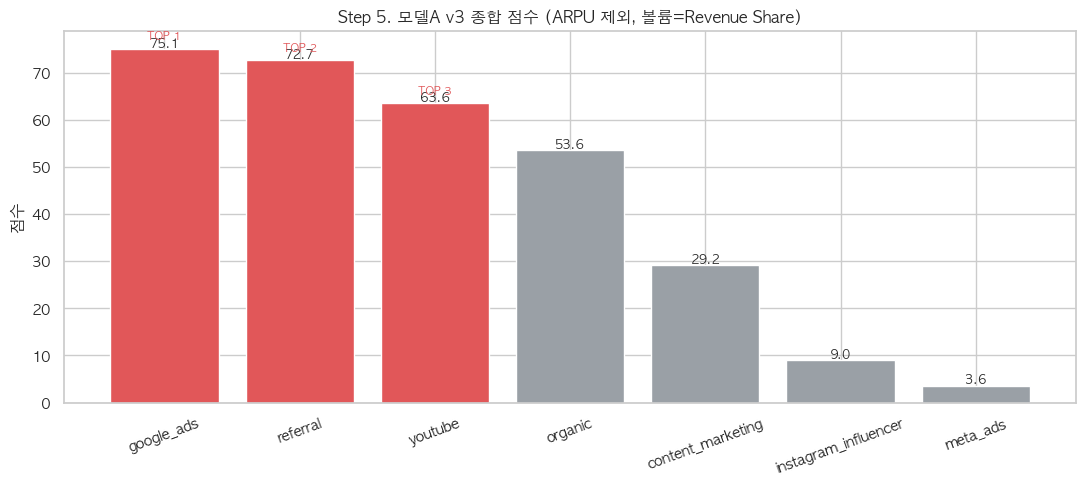

[모델 A v3] 상위 3채널: google_ads, referral, youtube


In [451]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager

# 분석 기간 코호트 (3개월 스냅샷)
start_dt = pd.Timestamp('2025-03-01')
end_dt = pd.Timestamp('2025-05-31')
users = pd.read_csv('data/users.csv', parse_dates=['signup_date'])
payments = pd.read_csv('data/payment_transactions.csv', parse_dates=['transaction_date'])
campaigns = pd.read_csv('data/campaigns.csv', parse_dates=['start_date', 'end_date'])
events = pd.read_csv('data/event_logs.csv', parse_dates=['event_timestamp'])

font_candidates = ['NanumGothic', 'Malgun Gothic', 'AppleGothic']
installed = {f.name for f in font_manager.fontManager.ttflist}
for f in font_candidates:
    if f in installed:
        plt.rcParams['font.family'] = f
        break
plt.rcParams['axes.unicode_minus'] = False

cohort = users[(users['signup_date'] >= start_dt) & (users['signup_date'] <= end_dt)].copy()
cohort_ids = cohort['user_id'].unique()

# 결제/매출
paid = payments[(payments['user_id'].isin(cohort_ids)) & (payments['status'] == 'completed')]
revenue = paid.groupby('user_id', as_index=False)['amount'].sum()
merged = pd.merge(cohort[['user_id', 'acquisition_source', 'signup_date']], revenue, on='user_id', how='left').fillna(0)
merged['is_paid'] = merged['amount'] > 0

ch = merged.groupby('acquisition_source').agg(
    user_count=('user_id', 'count'),
    paid_count=('is_paid', 'sum'),
    cvr=('is_paid', 'mean'),
    arpu=('amount', 'mean'),
    total_revenue=('amount', 'sum')
).reset_index()

# 캠페인 지출
camps = campaigns.copy()
camps['p_end'] = camps['end_date'].fillna(end_dt)

def get_spend(row):
    s = max(row['start_date'], start_dt)
    e = min(row['p_end'], end_dt)
    days = max(0, (e - s).days + 1)
    return days * row['daily_budget']

camps['spend'] = camps.apply(get_spend, axis=1)
spend_by_ch = camps.groupby('channel', as_index=False)['spend'].sum()

ch = pd.merge(ch, spend_by_ch, left_on='acquisition_source', right_on='channel', how='left').fillna(0)

# 비용 0원 채널 재정의(SEO/콘텐츠/추천 운영비 반영)
paid_cac_median = (ch[ch['spend'] > 0]['spend'] / ch[ch['spend'] > 0]['user_count']).median()
proxy_cac_map = {
    'organic': paid_cac_median * 0.20,
    'content_marketing': paid_cac_median * 0.35,
    'referral': paid_cac_median * 0.15
}

ch['proxy_cac'] = ch['acquisition_source'].map(proxy_cac_map)
ch['spend_adj'] = np.where(ch['spend'] > 0, ch['spend'], ch['proxy_cac'] * ch['user_count'])
ch['cac_adj'] = np.where(ch['user_count'] > 0, ch['spend_adj'] / ch['user_count'], 0)
ch['ltv_cac_adj'] = np.where(ch['cac_adj'] > 0, ch['arpu'] / ch['cac_adj'], np.nan)

# 리텐션
ev = events[events['user_id'].isin(cohort_ids)].merge(cohort[['user_id', 'signup_date', 'acquisition_source']], on='user_id')
ev['gap_days'] = (ev['event_timestamp'].dt.normalize() - ev['signup_date'].dt.normalize()).dt.days
d7_ids = ev[(ev['gap_days'] >= 1) & (ev['gap_days'] <= 7)]['user_id'].unique()
d30_ids = ev[(ev['gap_days'] >= 15) & (ev['gap_days'] <= 30)]['user_id'].unique()
merged['d7'] = merged['user_id'].isin(d7_ids)
merged['d30'] = merged['user_id'].isin(d30_ids)

ret = merged.groupby('acquisition_source').agg(
    d7_rate=('d7', 'mean'),
    d30_rate=('d30', 'mean')
).reset_index()

base_df = pd.merge(ch, ret, on='acquisition_source')

def norm(s):
    if s.max() == s.min():
        return pd.Series([100] * len(s), index=s.index)
    return (s - s.min()) / (s.max() - s.min()) * 100

def to_grade(x):
    if x >= 85:
        return 'S'
    if x >= 70:
        return 'A'
    if x >= 55:
        return 'B'
    if x >= 40:
        return 'C'
    return 'D'

base_df['revenue_share_pct'] = np.where(base_df['total_revenue'].sum() > 0, base_df['total_revenue'] / base_df['total_revenue'].sum() * 100, 0)
base_df['ltv_cac_filled'] = base_df['ltv_cac_adj'].fillna(base_df['ltv_cac_adj'].median())
base_df['s_roi'] = norm(base_df['ltv_cac_filled'])
base_df['s_cvr'] = norm(base_df['cvr'])
base_df['s_volume'] = norm(base_df['revenue_share_pct'])
base_df['s_ret'] = norm(base_df['d7_rate'] + base_df['d30_rate'])

# 모델A(v3): ARPU 제외, 볼륨은 revenue share로 정의
# 가중치(요청 반영): ROI 15% + CVR 35% + Volume(Revenue Share) 35% + Retention 15%
base_df['final_score_roi'] = (
    base_df['s_roi'] * 0.15 +
    base_df['s_cvr'] * 0.35 +
    base_df['s_volume'] * 0.35 +
    base_df['s_ret'] * 0.15
)

roi_df = base_df.sort_values('final_score_roi', ascending=False).reset_index(drop=True)

print('=== [모델 A v3] 종합 스코어 (ARPU 제외, 볼륨=Revenue Share) ===')
display(
    roi_df[['acquisition_source', 'user_count', 'total_revenue', 'revenue_share_pct', 'cvr', 'spend_adj', 'cac_adj', 'ltv_cac_adj', 'final_score_roi']]
    .rename(columns={'final_score_roi': 'final_score'})
    .style
    .format({
        'user_count': '{:,.0f}',
        'total_revenue': '{:,.0f}',
        'cvr': '{:.1%}',
        'revenue_share_pct': '{:.1f}%',
        'spend_adj': '{:,.0f}',
        'cac_adj': '{:,.1f}',
        'ltv_cac_adj': '{:.2f}',
        'final_score': '{:.1f}'
    })
    .highlight_max(subset=['final_score'], color='#d9ead3')
)

roi_grade = roi_df[['acquisition_source', 'final_score_roi']].copy()
roi_grade['grade'] = roi_grade['final_score_roi'].apply(to_grade)
print('=== [모델 A v3] 등급표 ===')
display(roi_grade.rename(columns={'acquisition_source': '채널', 'final_score_roi': '종합점수', 'grade': '등급'}).style.format({'종합점수': '{:.1f}'}))

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#e15759' if i < 3 else '#9aa0a6' for i in range(len(roi_df))]
bars = ax.bar(roi_df['acquisition_source'], roi_df['final_score_roi'], color=colors)
for i, b in enumerate(bars):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{b.get_height():.1f}", ha='center', va='bottom', fontsize=9)
    if i < 3:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1.5, f"TOP {i+1}", ha='center', va='bottom', fontsize=8, color='#e15759', fontweight='bold')
ax.set_title('Step 5. 모델A v3 종합 점수 (ARPU 제외, 볼륨=Revenue Share)')
ax.set_ylabel('점수')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

print('[모델 A v3] 상위 3채널:', ', '.join(roi_df.head(3)['acquisition_source']))







## Step 6. 연령대 × 채널 전환율
코드 설명:
- 연령대와 채널 교차 전환율을 히트맵으로 시각화해 핵심 코호트를 찾습니다.



acquisition_source,content_marketing,google_ads,instagram_influencer,meta_ads,organic,referral,youtube
age_group,,,,,,,
20-24,23.0%,31.3%,14.2%,19.1%,25.2%,31.5%,27.7%
25-29,18.2%,30.8%,22.6%,17.5%,23.0%,31.7%,28.3%
30-34,21.9%,31.6%,20.6%,16.6%,24.3%,36.2%,30.8%
35-39,27.8%,28.8%,16.0%,18.5%,23.9%,35.0%,28.3%
40+,26.2%,32.3%,26.1%,17.5%,22.7%,28.1%,26.9%


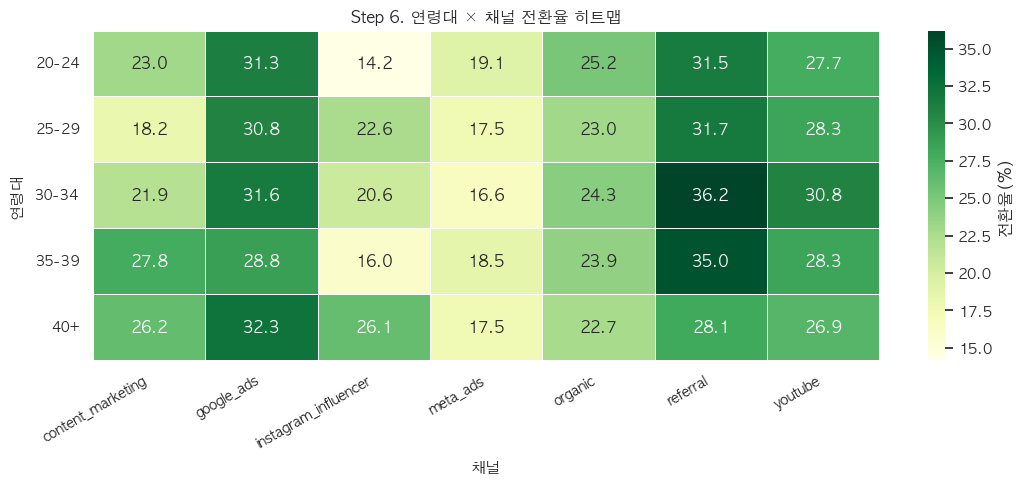

최고 조합: 30-34 + referral (36.2%)


In [452]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager

u = pd.read_csv('data/users.csv', parse_dates=['signup_date']).query("signup_date >= '2025-03-01' and signup_date <= '2025-05-31'").copy()
plan = pd.read_csv('data/plan_history.csv', parse_dates=['action_date'])
font_candidates = ['NanumGothic', 'Malgun Gothic', 'AppleGothic']
installed = {f.name for f in font_manager.fontManager.ttflist}
for f in font_candidates:
    if f in installed:
        plt.rcParams['font.family'] = f
        break
plt.rcParams['axes.unicode_minus'] = False

paid_users = set(plan.loc[plan['action'] == 'subscribe', 'user_id'])
u['is_paid'] = u['user_id'].isin(paid_users)

tmp = u.groupby(['age_group', 'acquisition_source'], as_index=False).agg(signups=('user_id', 'count'), paid_users=('is_paid', 'sum'))
tmp['paid_conversion_pct'] = (tmp['paid_users'] / tmp['signups'] * 100).round(1)
pivot6 = tmp.pivot(index='age_group', columns='acquisition_source', values='paid_conversion_pct').fillna(0)

display(pivot6.style.format('{:.1f}%').highlight_max(axis=None, color='#d9ead3'))

plt.figure(figsize=(11, 5))
sns.heatmap(
    pivot6,
    annot=True,
    fmt='.1f',
    cmap='YlGn',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': '전환율(%)'}
)
plt.title('Step 6. 연령대 × 채널 전환율 히트맵')
plt.xlabel('채널', fontsize=11, labelpad=8)
plt.ylabel('연령대', fontsize=11, labelpad=8)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

best = tmp.loc[tmp['paid_conversion_pct'].idxmax(), ['age_group', 'acquisition_source', 'paid_conversion_pct']]
print(f"최고 조합: {best['age_group']} + {best['acquisition_source']} ({best['paid_conversion_pct']:.1f}%)")
# 인사이트: 특정 연령대-채널 조합에서 전환율이 집중되므로 연령 타겟팅이 CAC 절감에 직접 기여한다.
# 인사이트: 최고 전환 조합은 크리에이티브/메시지 맞춤 집행의 1순위 세그먼트다.



## Step 7. 디바이스 × 채널 전환율
코드 설명:
- 디바이스와 채널 교차 전환율을 비교해 집행 우선 디바이스를 도출합니다.



acquisition_source,content_marketing,google_ads,instagram_influencer,meta_ads,organic,referral,youtube
device_type,,,,,,,
android,16.0%,22.4%,12.2%,13.5%,16.0%,23.0%,20.0%
ios,21.0%,28.5%,17.2%,14.0%,23.9%,30.8%,25.7%
web,25.9%,37.5%,26.8%,22.8%,28.0%,40.3%,36.4%


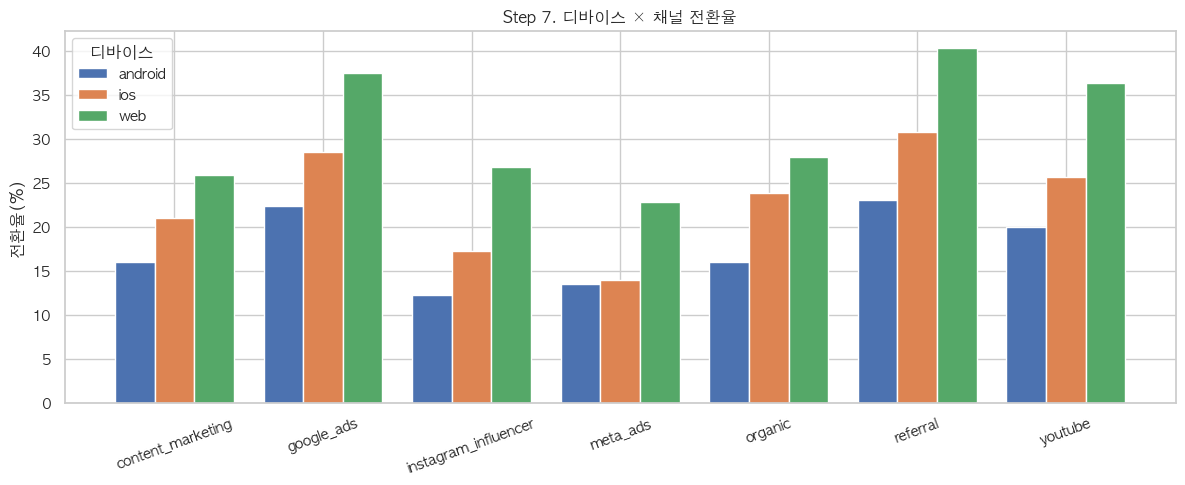

우선 디바이스 타겟: web (평균 전환율 31.1%)


In [453]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager

u = pd.read_csv('data/users.csv', parse_dates=['signup_date']).query("signup_date >= '2025-03-01' and signup_date <= '2025-05-31'").copy()
plan = pd.read_csv('data/plan_history.csv', parse_dates=['action_date'])
font_candidates = ['NanumGothic', 'Malgun Gothic', 'AppleGothic']
installed = {f.name for f in font_manager.fontManager.ttflist}
for f in font_candidates:
    if f in installed:
        plt.rcParams['font.family'] = f
        break
plt.rcParams['axes.unicode_minus'] = False

paid_users = set(plan.loc[plan['action'] == 'subscribe', 'user_id'])
u['is_paid'] = u['user_id'].isin(paid_users)

tmp = u.groupby(['device_type', 'acquisition_source'], as_index=False).agg(signups=('user_id', 'count'), paid_users=('is_paid', 'sum'))
tmp['paid_conversion_pct'] = (tmp['paid_users'] / tmp['signups'] * 100).round(1)
pivot7 = tmp.pivot(index='device_type', columns='acquisition_source', values='paid_conversion_pct').fillna(0)

display(pivot7.style.format('{:.1f}%').highlight_max(axis=0, color='#d9ead3'))

channels = pivot7.columns.tolist()
devices = pivot7.index.tolist()
x = np.arange(len(channels))
w = 0.8 / len(devices)
fig, ax = plt.subplots(figsize=(12, 5))
for i, dev in enumerate(devices):
    ax.bar(x + (i - (len(devices)-1)/2) * w, pivot7.loc[dev].values, width=w, label=dev)
ax.set_xticks(x)
ax.set_xticklabels(channels, rotation=20)
ax.set_ylabel('전환율(%)')
ax.set_title('Step 7. 디바이스 × 채널 전환율')
ax.legend(title='디바이스')
plt.tight_layout()
plt.show()

best_device = tmp.groupby('device_type', as_index=False)['paid_conversion_pct'].mean().sort_values('paid_conversion_pct', ascending=False).iloc[0]
print(f"우선 디바이스 타겟: {best_device['device_type']} (평균 전환율 {best_device['paid_conversion_pct']:.1f}%)")
# 인사이트: 디바이스별 전환율 격차가 뚜렷하면 입찰/소재를 디바이스 단위로 분리해야 효율이 오른다.
# 인사이트: 평균 전환율이 가장 높은 디바이스를 광고 기본 타겟으로 우선 배치하는 전략이 유효하다.


## Step 8. Step 5 모델A 기반 실행 세그먼트 도출
코드 설명:
- Step5 점수 결과를 기반으로 실제 집행 채널과 코호트 실행안을 연결합니다.



## Step 8-1. 집행 Top3 채널 선정 및 코호트 점수 계산
코드 설명:
- 집행 채널 Top3를 선정하고 코호트 점수를 계산합니다.
- 연령 코호트는 `10살 간격(20s/30s/40+)`으로 재분류해 분석합니다.



In [454]:
import pandas as pd
import numpy as np

u = pd.read_csv('data/users.csv', parse_dates=['signup_date']).query("signup_date >= '2025-03-01' and signup_date <= '2025-05-31'").copy()
# 연령 코호트 10살 간격 재분류
age_10_map = {
    '20-24': '20s',
    '25-29': '20s',
    '30-34': '30s',
    '35-39': '30s',
    '40+': '40+'
}
u['age_bucket_10y'] = u['age_group'].map(age_10_map).fillna(u['age_group'])

plan = pd.read_csv('data/plan_history.csv', parse_dates=['action_date'])
pay = pd.read_csv('data/payment_transactions.csv', parse_dates=['transaction_date'])

def minmax(s):
    if s.max() == s.min():
        return pd.Series([100] * len(s), index=s.index)
    return (s - s.min()) / (s.max() - s.min()) * 100

# Step5 결과에서 '집행 가능한 채널' 우선 선정
# organic/content_marketing은 성과 진단 채널로는 보되, 유료 집행 Top3에서는 제외
if 'roi_df' in globals() and 'final_score_roi' in roi_df.columns:
    execution_exclude = {'organic', 'content_marketing'}
    exec_pool = roi_df[~roi_df['acquisition_source'].isin(execution_exclude)].copy()
    top3_channels = exec_pool.head(3)['acquisition_source'].tolist()
else:
    raise RuntimeError('Step 5(모델A) 결과가 필요합니다. 먼저 Step 5를 실행해주세요.')

print('Step 8-1 분석 채널(집행 Top3):', ', '.join(top3_channels))

# 채널 우선순위 점수(모델A)
cs = roi_df[['acquisition_source', 'final_score_roi']].copy()
cs = cs[cs['acquisition_source'].isin(top3_channels)].copy()
cs['channel_priority_score'] = minmax(cs['final_score_roi'])

# Step6/7 기반 코호트 성과(연령×디바이스)
paid_users_plan = set(plan.loc[plan['action'] == 'subscribe', 'user_id'])
u['is_paid'] = u['user_id'].isin(paid_users_plan)

seg = u[u['acquisition_source'].isin(top3_channels)].groupby(
    ['acquisition_source', 'age_bucket_10y', 'device_type'], as_index=False
).agg(signups=('user_id', 'count'), paid_users=('is_paid', 'sum'))
seg['conversion_pct'] = np.where(seg['signups'] > 0, seg['paid_users'] / seg['signups'], 0)

pay_ok = pay[(pay['status'] == 'completed') & (pay['user_id'].isin(u['user_id']))].copy()
seg_pay = pay_ok.merge(u[['user_id', 'acquisition_source', 'age_bucket_10y', 'device_type']], on='user_id', how='inner')
seg_rev = seg_pay.groupby(['acquisition_source', 'age_bucket_10y', 'device_type'], as_index=False).agg(revenue=('amount', 'sum'))
seg = seg.merge(seg_rev, on=['acquisition_source', 'age_bucket_10y', 'device_type'], how='left').fillna(0)
seg['ARPU'] = np.where(seg['signups'] > 0, seg['revenue'] / seg['signups'], 0)

# 출력 호환을 위해 age_group 컬럼명으로 변환
seg = seg.rename(columns={'age_bucket_10y':'age_group'})

# 통합 점수: 채널우선(50) + 전환율(30) + ARPU(20)
seg = seg.merge(cs[['acquisition_source', 'channel_priority_score']], on='acquisition_source', how='left')
seg['n_cvr'] = minmax(seg['conversion_pct'])
seg['n_arpu'] = minmax(seg['ARPU'])
seg['score_8'] = seg['channel_priority_score'] * 0.50 + seg['n_cvr'] * 0.30 + seg['n_arpu'] * 0.20
seg = seg.sort_values('score_8', ascending=False).reset_index(drop=True)



Step 8-1 분석 채널(집행 Top3): google_ads, referral, youtube


## Step 8-2. 채널별 코호트 TOP 5
코드 설명:
- 집행 Top3 각 채널 내부에서 고가치 코호트 상위 5개를 선별합니다.



In [455]:
from IPython.display import display

if 'seg' not in globals() or 'top3_channels' not in globals():
    raise RuntimeError('Step 8-1을 먼저 실행해주세요.')

print('=== 채널별 코호트 TOP 5 ===')
for ch in top3_channels:
    out = (
        seg[seg['acquisition_source'] == ch][['age_group', 'device_type', 'signups', 'conversion_pct', 'ARPU', 'score_8']]
        .sort_values('score_8', ascending=False)
        .head(5)
        .reset_index(drop=True)
    )
    out.insert(0, 'rank', out.index + 1)

    print(f"\n[{ch}] 코호트 TOP 5")
    styled = (
        out.style
        .format({'signups':'{:,.0f}', 'conversion_pct':'{:.1%}', 'ARPU':'{:,.0f}', 'score_8':'{:.1f}'})
        .background_gradient(subset=['score_8'], cmap='YlGn')
        .background_gradient(subset=['conversion_pct'], cmap='GnBu')
        .set_properties(**{'text-align':'center', 'font-size':'10pt'})
        .set_table_styles([
            {'selector':'th', 'props':'background-color:#f3f7f3; color:#1f2937; text-align:center; font-weight:bold;'},
            {'selector':'td', 'props':'padding:6px;'}
        ])
        .hide(axis='index')
    )
    display(styled)



=== 채널별 코호트 TOP 5 ===

[google_ads] 코호트 TOP 5


rank,age_group,device_type,signups,conversion_pct,ARPU,score_8
1,40+,web,77,42.9%,"31,083",98.9
2,20s,web,448,38.4%,"23,934",88.8
3,30s,web,392,35.5%,"24,396",86.2
4,20s,ios,318,29.2%,"19,760",76.4
5,40+,ios,42,28.6%,"17,948",74.3



[referral] 코호트 TOP 5


rank,age_group,device_type,signups,conversion_pct,ARPU,score_8
1,30s,web,157,43.9%,"24,931",84.8
2,20s,web,192,38.5%,"21,086",76.4
3,40+,web,23,30.4%,"24,626",71.1
4,30s,ios,116,31.9%,"20,459",69.2
5,20s,ios,123,30.9%,"16,881",65.4



[youtube] 코호트 TOP 5


rank,age_group,device_type,signups,conversion_pct,ARPU,score_8
1,20s,web,374,38.0%,"23,549",38.1
2,30s,web,335,35.2%,"22,607",34.6
3,40+,web,65,33.8%,"19,845",31.0
4,30s,ios,278,27.7%,"15,503",21.5
5,40+,android,32,21.9%,"20,172",19.3


## Step 8-3. 통합 코호트 결과표 (한 번에 보기)
코드 설명:
- 채널별 TOP5를 합본으로 정렬해 실행 우선순위를 한 번에 봅니다.



In [456]:
from IPython.display import display

if 'seg' not in globals():
    raise RuntimeError('Step 8-1을 먼저 실행해주세요.')

# 채널별 상위 5개를 합쳐 통합표 생성
seg_top5_by_channel = (
    seg.sort_values('score_8', ascending=False)
       .groupby('acquisition_source', as_index=False)
       .head(5)
       .copy()
)

# 통합표는 점수 기준 재정렬
seg_all_view = (
    seg_top5_by_channel[['acquisition_source', 'age_group', 'device_type', 'signups', 'conversion_pct', 'ARPU', 'score_8']]
    .sort_values('score_8', ascending=False)
    .reset_index(drop=True)
)
seg_all_view.insert(0, 'rank', seg_all_view.index + 1)

print('=== Step 8-3 통합 코호트 결과표 (채널별 TOP5 합본) ===')
styled_all = (
    seg_all_view.style
    .format({'signups':'{:,.0f}', 'conversion_pct':'{:.1%}', 'ARPU':'{:,.0f}', 'score_8':'{:.1f}'})
    .background_gradient(subset=['score_8'], cmap='YlGn')
    .background_gradient(subset=['ARPU'], cmap='GnBu')
    .set_properties(**{'text-align':'center', 'font-size':'10pt'})
    .set_table_styles([
        {'selector':'th', 'props':'background-color:#eef6ee; color:#111827; text-align:center; font-weight:bold;'},
        {'selector':'td', 'props':'padding:6px;'}
    ])
    .hide(axis='index')
)
display(styled_all)

best = seg_all_view.iloc[0]
print('최우선 실행 세그먼트:', f"{best['acquisition_source']} | {best['age_group']} | {best['device_type']}")



=== Step 8-3 통합 코호트 결과표 (채널별 TOP5 합본) ===


rank,acquisition_source,age_group,device_type,signups,conversion_pct,ARPU,score_8
1,google_ads,40+,web,77,42.9%,"31,083",98.9
2,google_ads,20s,web,448,38.4%,"23,934",88.8
3,google_ads,30s,web,392,35.5%,"24,396",86.2
4,referral,30s,web,157,43.9%,"24,931",84.8
5,google_ads,20s,ios,318,29.2%,"19,760",76.4
6,referral,20s,web,192,38.5%,"21,086",76.4
7,google_ads,40+,ios,42,28.6%,"17,948",74.3
8,referral,40+,web,23,30.4%,"24,626",71.1
9,referral,30s,ios,116,31.9%,"20,459",69.2
10,referral,20s,ios,123,30.9%,"16,881",65.4


최우선 실행 세그먼트: google_ads | 40+ | web


## Step 8-4. 시각화
코드 설명:
- 채널별 최고 코호트와 통합 Top10을 시각적으로 비교합니다.



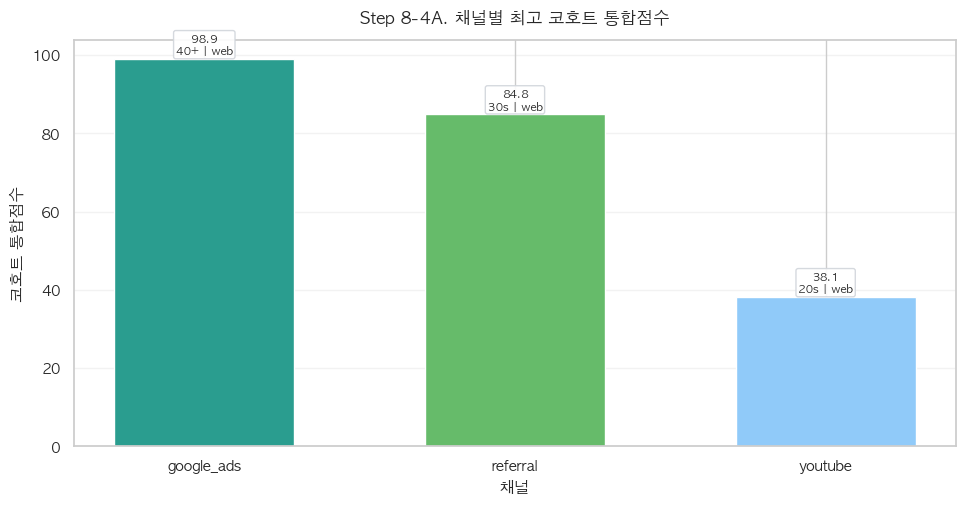

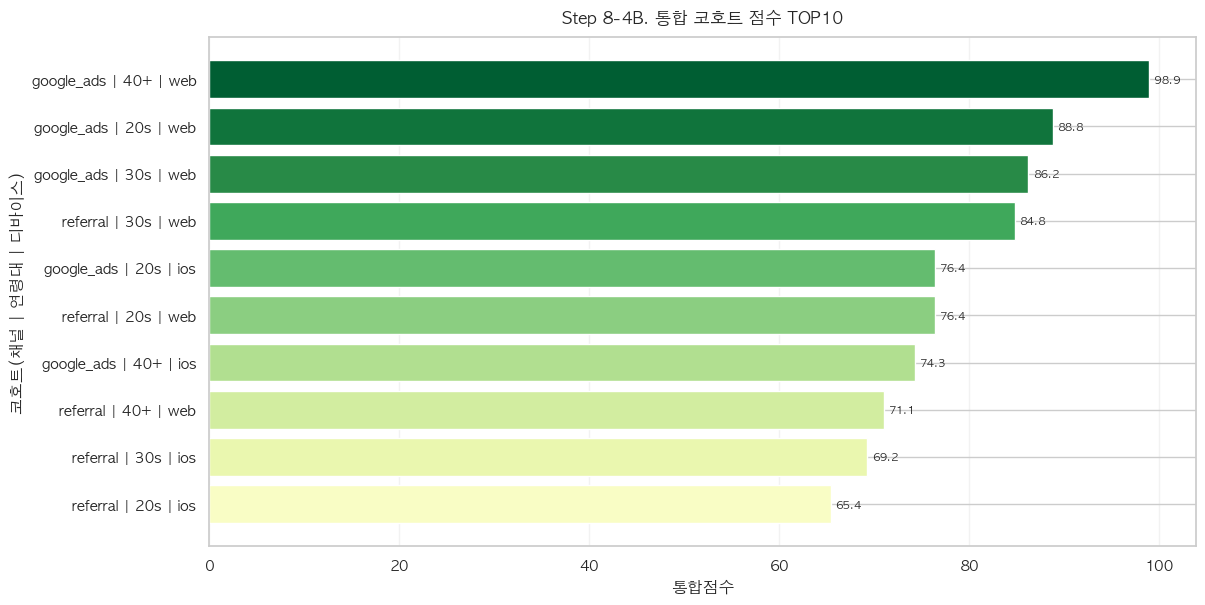

In [457]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

if 'seg' not in globals() or 'seg_all_view' not in globals():
    raise RuntimeError('Step 8-1~8-3을 먼저 실행해주세요.')

# 한글 폰트 고정(환경별 fallback)
font_candidates = ['NanumGothic', 'Malgun Gothic', 'AppleGothic']
installed = {f.name for f in font_manager.fontManager.ttflist}
for f in font_candidates:
    if f in installed:
        plt.rcParams['font.family'] = f
        break
plt.rcParams['axes.unicode_minus'] = False

# seaborn theme 적용 시 폰트가 덮어씌워지지 않도록 rc로 고정
sns.set_theme(style='whitegrid', font_scale=0.95, rc={'font.family': plt.rcParams['font.family'], 'axes.unicode_minus': False})

# 1) 채널별 최고 코호트 점수
best_by_channel = (
    seg.sort_values('score_8', ascending=False)
       .groupby('acquisition_source', as_index=False)
       .head(1)
       .sort_values('score_8', ascending=False)
)

fig, ax = plt.subplots(figsize=(9.8, 5.2))
palette = ['#2a9d8f', '#66bb6a', '#90caf9']
bars = ax.bar(best_by_channel['acquisition_source'], best_by_channel['score_8'], color=palette[:len(best_by_channel)], width=0.58)

for b, (_, r) in zip(bars, best_by_channel.iterrows()):
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + 0.7,
        f"{b.get_height():.1f}\n{r['age_group']} | {r['device_type']}",
        ha='center',
        va='bottom',
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#d1d5db', alpha=0.9)
    )
ax.set_title('Step 8-4A. 채널별 최고 코호트 통합점수', fontsize=12, pad=12)
ax.set_ylabel('코호트 통합점수')
ax.set_xlabel('채널')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# 2) 통합 TOP10 코호트 랭킹
viz = seg_all_view.head(10).copy()
viz['label'] = viz['acquisition_source'] + ' | ' + viz['age_group'] + ' | ' + viz['device_type']
viz = viz.sort_values('score_8', ascending=True)

fig, ax = plt.subplots(figsize=(12.2, 6.2))
bar_colors = sns.color_palette('YlGn', n_colors=len(viz))
ax.barh(viz['label'], viz['score_8'], color=bar_colors)
for y, s in zip(viz['label'], viz['score_8']):
    ax.text(s + 0.5, y, f"{s:.1f}", va='center', fontsize=8)
ax.set_title('Step 8-4B. 통합 코호트 점수 TOP10', fontsize=12, pad=10)
ax.set_xlabel('통합점수')
ax.set_ylabel('코호트(채널 | 연령대 | 디바이스)')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()




## Step 9. Step 8 기반 최종 실행안 요약
코드 설명:
- Step8 결과를 채널 우선순위/예산/액션으로 연결하는 최종 실행 단계입니다.



## Step 9-1. 최종 실행 요약표
코드 설명:
- 채널별 우선점수, 대표 코호트, 권장 예산 비중을 표로 요약합니다.



In [458]:
import pandas as pd
import numpy as np
from IPython.display import display

if 'seg_all_view' not in globals() or 'score_8' not in seg_all_view.columns:
    raise RuntimeError('Step 8-3를 먼저 실행해주세요. (seg_all_view 필요)')
if 'top3_channels' not in globals():
    raise RuntimeError('Step 8-1을 먼저 실행해주세요. (top3_channels 필요)')

# Step 8 결과만 사용
source = seg_all_view[seg_all_view['acquisition_source'].isin(top3_channels)].copy()

# 채널별 대표/요약 지표
best = (
    source.sort_values('score_8', ascending=False)
    .groupby('acquisition_source', as_index=False)
    .head(1)
    [['acquisition_source', 'age_group', 'device_type', 'conversion_pct', 'ARPU', 'score_8']]
    .rename(columns={
        'conversion_pct':'best_cvr',
        'ARPU':'best_arpu',
        'score_8':'best_score'
    })
)

agg = source.groupby('acquisition_source', as_index=False).agg(
    avg_score=('score_8', 'mean'),
    avg_cvr=('conversion_pct', 'mean'),
    avg_arpu=('ARPU', 'mean'),
    total_signups=('signups', 'sum')
)

final = agg.merge(best, on='acquisition_source', how='left')
final['priority_score'] = final['avg_score'] * 0.6 + final['best_score'] * 0.4
final = final.sort_values('priority_score', ascending=False).reset_index(drop=True)

# 권장 예산 비중(100% 합)
final['recommended_budget_pct'] = (final['priority_score'] / final['priority_score'].sum() * 100).round(1)
final['priority'] = ['P1', 'P2', 'P3'][:len(final)]
final['best_cohort'] = final['age_group'] + ' | ' + final['device_type']

summary = final[['priority','acquisition_source','priority_score','recommended_budget_pct','best_cohort','best_cvr','best_arpu','avg_score']].copy()

print('=== Step 9-1 최종 실행 요약표 (Step 8 기준) ===')
display(
    summary.rename(columns={
        'priority':'우선순위',
        'acquisition_source':'채널',
        'priority_score':'최종우선점수',
        'recommended_budget_pct':'권장예산비중(%)',
        'best_cohort':'대표 코호트(연령|디바이스)',
        'best_cvr':'대표 코호트 CVR',
        'best_arpu':'대표 코호트 ARPU',
        'avg_score':'채널 평균 코호트점수'
    })
    .style
    .format({
        '최종우선점수':'{:.1f}',
        '권장예산비중(%)':'{:.1f}',
        '대표 코호트 CVR':'{:.1%}',
        '대표 코호트 ARPU':'{:,.0f}',
        '채널 평균 코호트점수':'{:.1f}'
    })
    .background_gradient(subset=['최종우선점수','권장예산비중(%)'], cmap='YlGn')
    .hide(axis='index')
)



=== Step 9-1 최종 실행 요약표 (Step 8 기준) ===


우선순위,채널,최종우선점수,권장예산비중(%),대표 코호트(연령|디바이스),대표 코호트 CVR,대표 코호트 ARPU,채널 평균 코호트점수
P1,google_ads,90.5,45.0,40+ | web,42.9%,"31,083",84.9
P2,referral,78.0,38.8,30s | web,43.9%,"24,931",73.4
P3,youtube,32.6,16.2,20s | web,38.0%,"23,549",28.9


## Step 9-2. 최종 우선순위 시각화
코드 설명:
- 우선점수(막대)와 권장 예산(선)을 동시에 보여줍니다.



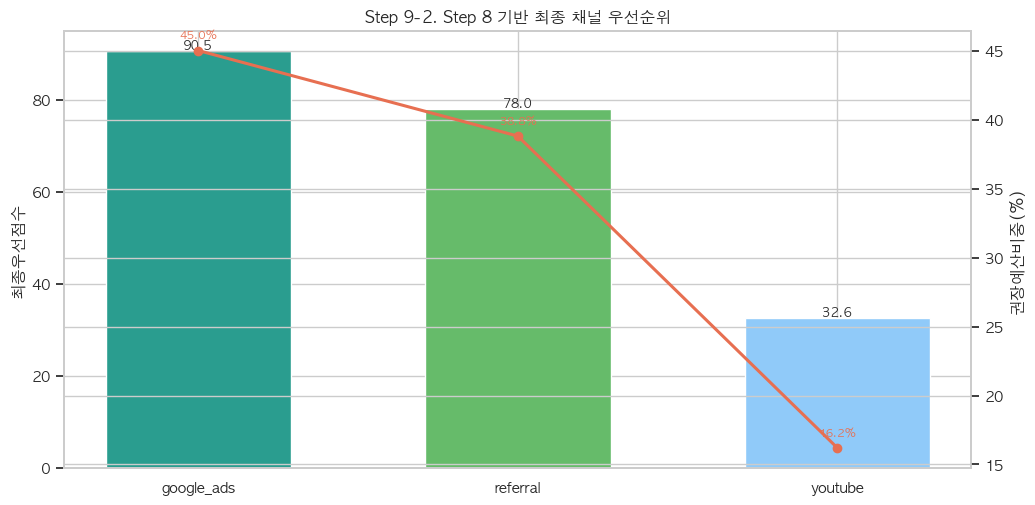

In [459]:
import matplotlib.pyplot as plt

if 'final' not in globals():
    raise RuntimeError('Step 9-1을 먼저 실행해주세요. (final 필요)')

# 시각화: 최종 우선점수 + 권장예산
fig, ax1 = plt.subplots(figsize=(10.5, 5.2))
x = np.arange(len(final))
bars = ax1.bar(x, final['priority_score'], color=['#2a9d8f','#66bb6a','#90caf9'][:len(final)], width=0.58)
ax1.set_xticks(x)
ax1.set_xticklabels(final['acquisition_source'])
ax1.set_ylabel('최종우선점수')
ax1.set_title('Step 9-2. Step 8 기반 최종 채널 우선순위')
for b in bars:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.1f}", ha='center', va='bottom', fontsize=9)

ax2 = ax1.twinx()
ax2.plot(x, final['recommended_budget_pct'], color='#e76f51', marker='o', linewidth=2.2)
ax2.set_ylabel('권장예산비중(%)')
for xi, yi in zip(x, final['recommended_budget_pct']):
    ax2.text(xi, yi + 0.7, f"{yi:.1f}%", ha='center', va='bottom', fontsize=8, color='#e76f51')

plt.tight_layout()
plt.show()



## Step 9-3. 최종 권고안
코드 설명:
- P1~P3 채널별 실행 우선순위를 문장형으로 출력합니다.



In [460]:
if 'final' not in globals():
    raise RuntimeError('Step 9-1을 먼저 실행해주세요. (final 필요)')

print('=== Step 9-3 최종 권고 ===')
for _, r in final.iterrows():
    print(f"- {r['priority']} {r['acquisition_source']}: 권장 예산 {r['recommended_budget_pct']:.1f}%, 대표 코호트={r['best_cohort']}")



=== Step 9-3 최종 권고 ===
- P1 google_ads: 권장 예산 45.0%, 대표 코호트=40+ | web
- P2 referral: 권장 예산 38.8%, 대표 코호트=30s | web
- P3 youtube: 권장 예산 16.2%, 대표 코호트=20s | web


## Step 9-4. 채널별 액션 후보 (최종)
코드 설명:
- 채널별 액션/목적/기대 시나리오를 실행 문장으로 제공합니다.



In [461]:
if 'final' not in globals():
    raise RuntimeError('Step 9-1을 먼저 실행해주세요. (final 필요)')

# Step 9 결과 기반 용어 설명 + 채널별 액션(목적/시나리오)
print('=== Step 9-4 채널별 액션 추천 (목적/기대 시나리오 포함) ===')
print('[용어 간단 설명]')
print('- CVR: 유입 대비 유료전환 비율')
print('- ARPU: 사용자 1인당 평균 매출')
print('- 리타겟팅: 이탈 가능성이 높은 유저를 다시 타겟해 재노출하는 방식')
print('- 네거티브 키워드: 비효율 검색어 노출을 차단해 광고비 낭비를 줄이는 키워드')
print('- A/B 테스트: 두 가지 버전을 병행 실험해 성과가 높은 안을 선택하는 방식')

for _, r in final.iterrows():
    ch = r['acquisition_source']
    cohort = r['best_cohort']
    budget = r['recommended_budget_pct']

    print()
    print(f"[{r['priority']}] {ch} | 권장 예산 {budget:.1f}% | 대표 코호트 {cohort}")

    if ch == 'referral':
        print('1) 액션: 결제 확정 기반 더블 리워드')
        print('   목적: 가입 수가 아니라 유료전환 수를 늘려 저리스크로 매출 효율을 높인다.')
        print('   기대 시나리오: 추천 가입 후 결제 완료 시점에만 보상이 지급되어, 비용 대비 순매출이 안정적으로 증가한다.')

        print('2) 액션: 추천 진입 퍼널 단축(링크→가입→결제) + A/B 테스트')
        print('   목적: 추천 유입의 이탈 구간을 줄여 전환 속도를 높인다.')
        print('   기대 시나리오: 추천 코드 입력/랜딩/결제 단계 마찰이 줄어 동일 트래픽 대비 CVR이 개선된다.')

        print('3) 액션: 상위 추천인 그룹 인센티브 분리 운영')
        print('   목적: 실제 매출 기여가 큰 추천인 집단에 예산을 집중한다.')
        print('   기대 시나리오: 고성과 추천인 활동량이 증가해 예측 가능한 반복 유입 구조가 강화된다.')

    elif ch == 'youtube':
        print('1) 액션: 체험 기간 내 조기 결제 프로모션')
        print('   목적: 7일 체험 후 이탈하는 유저를 조기에 유료로 전환한다.')
        print('   기대 시나리오: 체험 종료 전 결제 확정 비율이 올라가며, Q3(체험 이탈) 구간이 축소된다.')

        print('2) 액션: 대표 코호트 맞춤 크리에이티브(메시지/썸네일/CTA) 확장')
        print('   목적: 관심은 있지만 결제 직전에서 머무는 유저의 구매 의사를 자극한다.')
        print('   기대 시나리오: 코호트 적합도가 높은 소재에서 CTR과 랜딩 전환율이 동시에 개선된다.')

        print('3) 액션: 시청구간 기반 리타겟팅(완시청/중도이탈 분리)')
        print('   목적: 의도 수준이 다른 유저를 분리 공략해 전환 효율을 높인다.')
        print('   기대 시나리오: 완시청군은 결제 오퍼, 중도이탈군은 신뢰형 메시지로 재유입되어 전체 전환이 상승한다.')

    elif ch == 'google_ads':
        print('1) 액션: Pro 의도형 키워드 묶음 분리 + 전용 랜딩')
        print('   목적: 결제 가능성이 높은 검색 유입에만 예산을 집중한다.')
        print('   기대 시나리오: 유입량은 다소 줄어도 고의도 트래픽 비중이 올라 CPA 대비 매출 효율이 개선된다.')

        print('2) 액션: 검색어 리포트 기반 네거티브 키워드 확장')
        print('   목적: 비의도/저품질 클릭을 차단해 불필요한 광고비를 줄인다.')
        print('   기대 시나리오: 무효 트래픽이 감소하면서 동일 예산에서 유효 전환 수가 늘어난다.')

        print('3) 액션: 디바이스·시간대 입찰 가중치 조정(웹 중심)')
        print('   목적: 전환율이 높은 구간에 노출을 집중해 단기 효율을 높인다.')
        print('   기대 시나리오: 저성과 시간/디바이스 노출이 줄고, 상위 코호트 중심으로 전환 밀도가 높아진다.')

    else:
        print('1) 액션: 대표 코호트 전용 캠페인 분리 운영')
        print('   목적: 성과가 높은 세그먼트 중심으로 예산을 재배치한다.')
        print('   기대 시나리오: 평균 성과 하락 없이 상위 코호트의 기여도가 확대된다.')


=== Step 9-4 채널별 액션 추천 (목적/기대 시나리오 포함) ===
[용어 간단 설명]
- CVR: 유입 대비 유료전환 비율
- ARPU: 사용자 1인당 평균 매출
- 리타겟팅: 이탈 가능성이 높은 유저를 다시 타겟해 재노출하는 방식
- 네거티브 키워드: 비효율 검색어 노출을 차단해 광고비 낭비를 줄이는 키워드
- A/B 테스트: 두 가지 버전을 병행 실험해 성과가 높은 안을 선택하는 방식

[P1] google_ads | 권장 예산 45.0% | 대표 코호트 40+ | web
1) 액션: Pro 의도형 키워드 묶음 분리 + 전용 랜딩
   목적: 결제 가능성이 높은 검색 유입에만 예산을 집중한다.
   기대 시나리오: 유입량은 다소 줄어도 고의도 트래픽 비중이 올라 CPA 대비 매출 효율이 개선된다.
2) 액션: 검색어 리포트 기반 네거티브 키워드 확장
   목적: 비의도/저품질 클릭을 차단해 불필요한 광고비를 줄인다.
   기대 시나리오: 무효 트래픽이 감소하면서 동일 예산에서 유효 전환 수가 늘어난다.
3) 액션: 디바이스·시간대 입찰 가중치 조정(웹 중심)
   목적: 전환율이 높은 구간에 노출을 집중해 단기 효율을 높인다.
   기대 시나리오: 저성과 시간/디바이스 노출이 줄고, 상위 코호트 중심으로 전환 밀도가 높아진다.

[P2] referral | 권장 예산 38.8% | 대표 코호트 30s | web
1) 액션: 결제 확정 기반 더블 리워드
   목적: 가입 수가 아니라 유료전환 수를 늘려 저리스크로 매출 효율을 높인다.
   기대 시나리오: 추천 가입 후 결제 완료 시점에만 보상이 지급되어, 비용 대비 순매출이 안정적으로 증가한다.
2) 액션: 추천 진입 퍼널 단축(링크→가입→결제) + A/B 테스트
   목적: 추천 유입의 이탈 구간을 줄여 전환 속도를 높인다.
   기대 시나리오: 추천 코드 입력/랜딩/결제 단계 마찰이 줄어 동일 트래픽 대비 CVR이 개선된다.
3) 액션: 상위 추천인 그룹 인센티브 분리 운영
   목적: 실제 

## Step 9-5. 현재 예산 100% 기준 전체 채널 재배분안
코드 설명:
- 제약조건: `organic=0%`, `content_marketing=2%`, `referral=12%`, `instagram=8%`, `meta=10%`를 고정합니다.
- 남은 예산(68%)은 `google_ads`, `youtube` 두 채널에만 배분합니다.



In [462]:
import pandas as pd
import numpy as np
from IPython.display import display

if 'roi_df' not in globals():
    raise RuntimeError('Step 5를 먼저 실행해주세요. (roi_df 필요)')

budget_df = roi_df[['acquisition_source', 'final_score_roi']].copy()
budget_df = budget_df.rename(columns={'acquisition_source':'채널', 'final_score_roi':'score'})
budget_df = budget_df.sort_values('score', ascending=False).reset_index(drop=True)

# 집행 우선순위 고정: 1순위 google_ads, 2순위 youtube
boost = {ch: 1.0 for ch in budget_df['채널']}
preferred_boost = {
    'google_ads': 1.40,
    'youtube': 1.25,
}
for ch, v in preferred_boost.items():
    if ch in boost:
        boost[ch] = v

budget_df['focus_boost'] = budget_df['채널'].map(boost)
budget_df['budget_score'] = budget_df['score'] * budget_df['focus_boost']

# 고정 제약(요청 시나리오)
# - organic: 0%
# - content_marketing: 2%
# - referral: 12%
# - instagram_influencer: 8%
# - meta_ads: 10%
# 나머지(68%)는 google_ads / youtube에만 배분
fixed_alloc = {
    'organic': 0.0,
    'content_marketing': 2.0,
    'referral': 12.0,
    'instagram_influencer': 8.0,
    'meta_ads': 10.0,
}
remain_pct = 100.0 - sum(fixed_alloc.values())

budget_df['budget_pct'] = 0.0
mask_fixed = budget_df['채널'].isin(fixed_alloc.keys())
mask_variable = ~mask_fixed
mask_variable = mask_variable & budget_df['채널'].isin(['google_ads', 'youtube'])

variable_score_sum = budget_df.loc[mask_variable, 'budget_score'].sum()
if variable_score_sum > 0:
    budget_df.loc[mask_variable, 'budget_pct'] = (
        budget_df.loc[mask_variable, 'budget_score'] / variable_score_sum * remain_pct
    )

for ch, pct in fixed_alloc.items():
    idx = budget_df.index[budget_df['채널'] == ch]
    if len(idx) > 0:
        budget_df.loc[idx[0], 'budget_pct'] = pct

budget_df['budget_pct'] = budget_df['budget_pct'].round(1)

diff = round(100.0 - budget_df['budget_pct'].sum(), 1)
# 고정 채널이 아닌 상위 채널에 반올림 오차 보정
for i in budget_df.index:
    if budget_df.loc[i, '채널'] not in fixed_alloc:
        budget_df.loc[i, 'budget_pct'] = round(budget_df.loc[i, 'budget_pct'] + diff, 1)
        break

budget_plan = budget_df[['채널', 'score', 'focus_boost', 'budget_pct']].copy()
budget_plan = budget_plan.sort_values('budget_pct', ascending=False).reset_index(drop=True)

# 운영 tier는 '최종 배분 비율' 기준으로 부여
budget_plan['tier'] = '테스트'
budget_plan.loc[budget_plan.index < 3, 'tier'] = '집중'
budget_plan.loc[(budget_plan.index >= 3) & (budget_plan.index < 5), 'tier'] = '유지'
# 고정 제약 채널 표기 보정
budget_plan.loc[budget_plan['채널'] == 'organic', 'tier'] = '제외(0%)'
budget_plan.loc[budget_plan['채널'] == 'content_marketing', 'tier'] = '유지(소액)'

print('=== Step 9-5. 현재 예산 100% 재배분안 (전체 채널) ===')
print("제약조건: organic=0%, content_marketing=2%, referral=12%, instagram=8%, meta=10%")
print(f"총합: {budget_plan['budget_pct'].sum():.1f}%")
display(
    budget_plan.style
    .format({'score':'{:.1f}', 'focus_boost':'{:.2f}', 'budget_pct':'{:.1f}%'} )
    .background_gradient(subset=['budget_pct'], cmap='YlGn')
    .hide(axis='index')
)




=== Step 9-5. 현재 예산 100% 재배분안 (전체 채널) ===
제약조건: organic=0%, content_marketing=2%, referral=12%, instagram=8%, meta=10%
총합: 100.0%


채널,score,focus_boost,budget_pct,tier
google_ads,75.1,1.40,38.7%,집중
youtube,63.6,1.25,29.3%,집중
referral,72.7,1.00,12.0%,집중
meta_ads,3.6,1.00,10.0%,유지
instagram_influencer,9.0,1.00,8.0%,유지
content_marketing,29.2,1.00,2.0%,유지(소액)
organic,53.6,1.00,0.0%,제외(0%)


## Step 9-6. 전체 채널 예산 재배분 시각화
코드 설명:
- 100% 예산 재배분 결과를 채널별 비율 막대그래프로 표시합니다.



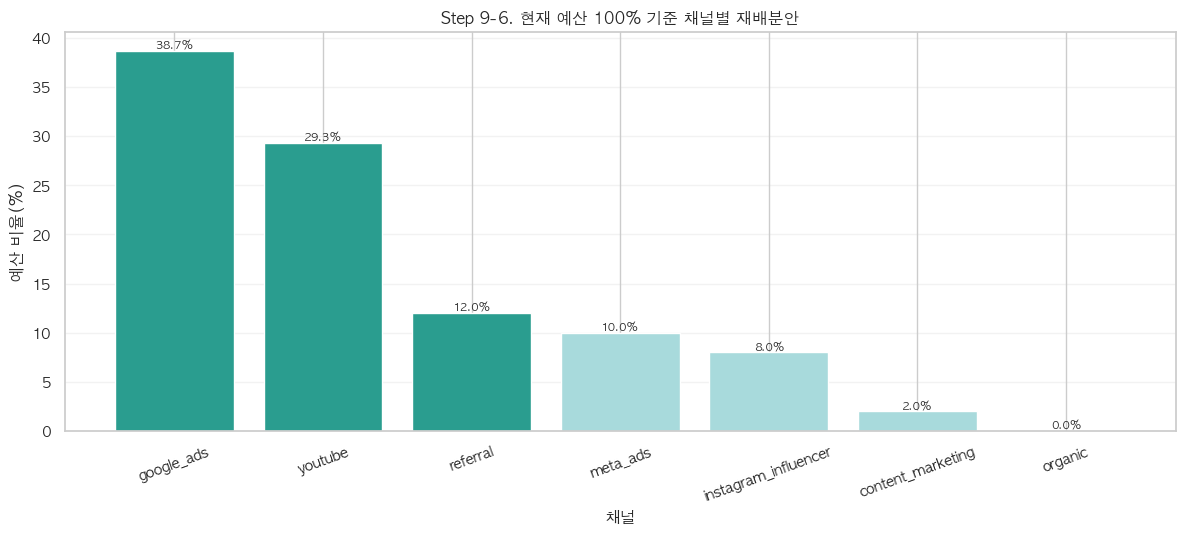

해석 가이드: organic 0%, content 2%, referral 12%, instagram 8%, meta 10%를 고정하고, 남은 68%를 google_ads·youtube에 배분합니다.


In [463]:
import matplotlib.pyplot as plt
import numpy as np

if 'budget_plan' not in globals():
    raise RuntimeError('Step 9-5를 먼저 실행해주세요. (budget_plan 필요)')

plot_df = budget_plan.sort_values('budget_pct', ascending=False).copy()
colors = ['#2a9d8f' if i < 3 else '#a8dadc' for i in range(len(plot_df))]

fig, ax = plt.subplots(figsize=(12, 5.5))
bars = ax.bar(plot_df['채널'], plot_df['budget_pct'], color=colors)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.1f}%", ha='center', va='bottom', fontsize=8)

ax.set_title('Step 9-6. 현재 예산 100% 기준 채널별 재배분안')
ax.set_ylabel('예산 비율(%)')
ax.set_xlabel('채널')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

print('해석 가이드: organic 0%, content 2%, referral 12%, instagram 8%, meta 10%를 고정하고, 남은 68%를 google_ads·youtube에 배분합니다.')

